# Multi-Label ESG Classification with Transformer Models

**Fernando Nakamoto**  


---

# 0.Project Overview

This project explores the use of transformer-based models for multi-label classification of ESG-related text. Using datasets derived from ClimateBERT, we model different dimensions of sustainability-related disclosures, including sentiment, specificity, and climate relevance.

Beyond the empirical implementation, we propose a conceptual architecture for a scalable ESG taxonomy classifier based on large language models. This notebook implements a reproducible demo for ESG text classification using transformer encoders.



# 1. Setup and Libraries

In [2]:
from IPython.display import Image, display
from IPython.display import HTML
import random
import numpy as np
import torch
from datasets import load_dataset, Dataset
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import warnings
from transformers import logging

warnings.filterwarnings("ignore")
logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
HTML("""<style>
/* =========Global notebook styling====== */
body {font-family: "Inter", "Helvetica Neue", Arial, sans-serif;background-color: #fafafa;color: #2f2f2f;line-height: 1.65;}    
/* =========H1 — Major Sections========== */
h1 {font-family: "Georgia", "Times New Roman", serif;font-size: 2.2em;font-weight: 600;color: #2c3e50;background: linear-gradient(90deg, #e8f0f2, #f7f9fa);padding: 16px 20px;border-radius: 12px;margin-top: 2.2em;margin-bottom: 1.2em;border-left: 8px solid #a8c3d6;}   
/* =========H2 — Subsections============= */
h2 {font-family: "Georgia", "Times New Roman", serif;font-size: 1.6em;font-weight: 500;color: #34495e;margin-top: 2em;margin-bottom: 0.8em;padding-left: 14px;border-left: 4px solid #c7dce8;}
/* =========H3 — Minor headings=========== */
h3 {font-size: 1.2em;font-weight: 600;color: #4a6572;margin-top: 1.4em;margin-bottom: 0.6em;}
/* =========Paragraphs==================== */
p {font-size: 1.02em;margin-bottom: 0.9em;}
/* =========Inline math & code============ */
code {background-color: #f1f3f4;color: #37474f;padding: 2px 6px;border-radius: 6px;font-size: 0.95em;}
/* =========Math blocks=================== */
.MathJax_Display {background: #f7f9fb;padding: 14px;border-radius: 10px;border-left: 4px solid #d6e4ec;}
/* =========Lists========================= */
ul li {margin-bottom: 0.4em;}
</style>""")

# 1. Introduction

The increasing demand for structured sustainability data has led to the emergence of ESG taxonomies. These frameworks aim to classify corporate activities according to environmental and social criteria.

However, most ESG data is unstructured, appearing in reports, disclosures, and financial documents. This creates a need for automated systems capable of extracting and classifying relevant information.

In this project, we explore how transformer-based models can be used to approximate such a system through multi-label text classification.

# 2. Problem Formulation
ESG text classification is often formulated as a single-label problem, where each document is assigned to one predefined category.  However, real-world sustainability disclosures are inherently multi-dimensional, as a single text segment may simultaneously express multiple ESG-related attributes.

This challenge becomes particularly evident in the context of sustainable taxonomies, such as the EU Taxonomy or similar classification frameworks, which aim to determine whether an economic activity is aligned with environmental goals. In practice, taxonomy alignment requires evaluating multiple criteria, including environmental relevance, technical specificity, carbon intensity and qualitative disclosures.

For example, a single paragraph in a corporate report may simultaneously: refer to climate-related topics (relevance); express a positive or negative stance (sentiment); provide either vague or detailed information (specificity); relate to a specific disclosure category (e.g., Task Force on Climate-related Financial Disclosures - TCFD).

This motivates a formulation in which, for a given input text $x$, the goal is to predict a vector of labels:

$$
y = [y_1, y_2, ..., y_k]
$$

where each $y_i$ represents a different ESG dimension.In this work, we leverage publicly available datasets from the ClimateBERT project [1] to model these ESG dimensions and explore the effectiveness of transformer-based approaches. Specifically, we fine-tune pretrained language models (e.g., BERT-based architectures) on each ESG classification task and evaluate their performance using standard metrics. In addition, we compare results across different model configurations to assess their relative effectiveness.

Finally, we use these findings to discuss the feasibility of scaling this approach toward a more general ESG taxonomy classification system, and propose a conceptual architecture for structuring unstructured sustainability disclosures using large language models.

# 3.Methodology

This section describes the complete pipeline used to perform multi-label ESG classification using transformer-based models. Given an input text $x$, the objective is to predict a vector of labels:

$$
y = [y_1, y_2, \dots, y_K]
$$

where:

- $x \in \mathcal{X}$ is a textual input (e.g., a paragraph from a sustainability report)
- $\mathcal{Y}_k$ is the label space for task $k$, which may be binary or multi-class
- $K$ is the number of ESG dimensions.

Thus, the model learns a function:

$$
f_\theta: \mathcal{X} \rightarrow \mathcal{Y}_1 \times \mathcal{Y}_2 \times \dots \times \mathcal{Y}_K
$$

where $\theta$ are the model parameters.

This work leverages multiple publicly available datasets from the ClimateBERT ecosystem, each designed to capture a specific semantic dimension of climate-related textual information.

The datasets used include:
- climate_sentiment
- environmental_claims
- tcfd_recommendations
- climate_specificity
- climate_detection

Each dataset consists of annotated text segments extracted primarily from corporate disclosures, sustainability reports, and other climate-related documents. Although these datasets are distributed as separate benchmarks, they are not fundamentally heterogeneous. Instead, they share a common underlying textual domain.

These datasets have relatively small size, typically ranging from approximately 1,000 to 3,000 labeled samples. This reflects the inherent difficulty and cost of expert annotation in the climate domain, where labels often require domain knowledge and contextual interpretation. The annotation process is rigorous and expert-driven. For example, in the environmental claims dataset, annotations are performed by multiple domain experts.

The datasets follow structured annotation guidelines, where annotators classify text according to well-defined criteria, including:

- climate detection (1 - yes, 0 - no)
- sentiment (0 - risk, 1 - neutral, 2 - opportunity)
- specificity (1 - specific vs. 0 - non-specific)
- TCFD recommendations (0 - none, 1 - metrics, 2 - strategy, 3 - risk, 4 - governance)
- environmental claims (1 - yes, 0 - no)

This setup reflects the inherently multi-dimensional nature of climate-related language, where a single text segment may simultaneously encode multiple semantic attributes. We construct a unified dataset by merging these multiple ClimateBERT datasets.


# 4. Solution


This section implements the full pipeline for ESG classification.

The pipeline consists of the following steps:

1. Load ClimateBERT datasets
2. Preprocess and merge datasets
3. Train transformer-based classifiers
4. Evaluate model performance
5. Visualize training behavior and prediction errors


## 4.1 Data loading

In [4]:
ds_detection = load_dataset("climatebert/climate_detection")
ds_sentiment = load_dataset("climatebert/climate_sentiment")
ds_specificity = load_dataset("climatebert/climate_specificity")
ds_tcfd = load_dataset("climatebert/tcfd_recommendations")
ds_claims = load_dataset("climatebert/environmental_claims")

## 4.2 Data processing

We convert each dataset into a pandas DataFrame and standardize the text field. Basic cleaning is applied to remove extra spaces and formatting inconsistencies.

In [5]:
def prepare_split(ds, split_name, label_col_name):
    df = ds[split_name].to_pandas().copy()
    df = df.rename(columns={"label": label_col_name})
    df["text"] = (
        df["text"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True))
    return df

## 4.3 Dataset Preparation

Each ClimateBERT dataset is processed into train and test splits. Each label is renamed according to its ESG dimension.

In [6]:
train_detection = prepare_split(ds_detection, "train", "climate_label")
test_detection  = prepare_split(ds_detection, "test",  "climate_label")
train_sentiment = prepare_split(ds_sentiment, "train", "sentiment_label")
test_sentiment  = prepare_split(ds_sentiment, "test",  "sentiment_label")
train_specificity = prepare_split(ds_specificity, "train", "specificity_label")
test_specificity  = prepare_split(ds_specificity, "test",  "specificity_label")
train_tcfd = prepare_split(ds_tcfd, "train", "tcfd_label")
test_tcfd  = prepare_split(ds_tcfd, "test",  "tcfd_label")
train_claims = prepare_split(ds_claims, "train", "claim_label")
test_claims  = prepare_split(ds_claims, "test",  "claim_label")

## 4.4 Dataset Inspection

We analyze overlap between datasets to determine whether they can be merged. The results show that multiple datasets share a common subset of texts, enabling exact merging.

In [7]:
print(len(train_detection))
print(len(train_sentiment))
print(len(train_specificity))
print(len(train_tcfd))
print(len(train_claims))

set_det = set(train_detection["text"])
set_sent = set(train_sentiment["text"])
set_spec = set(train_specificity["text"])
set_tcfd = set(train_tcfd["text"])
set_claim = set(train_claims["text"])

print("det x sent:", len(set_det & set_sent))
print("det x spec:", len(set_det & set_spec))
print("det x tcfd:", len(set_det & set_tcfd))
print("det x claim:", len(set_det & set_claim))
print("sent x spec:", len(set_sent & set_spec))
print("sent x tcfd:", len(set_sent & set_tcfd))
print("spec x tcfd:", len(set_spec & set_tcfd))

1300
1000
1000
1300
2117
det x sent: 1000
det x spec: 1000
det x tcfd: 1300
det x claim: 0
sent x spec: 1000
sent x tcfd: 1000
spec x tcfd: 1000


An inspection of the dataset intersections revealed that climate_detection, climate_sentiment, climate_specificity, and tcfd_recommendations share a common subset of text instances, enabling exact merging by text. In contrast, environmental_claims belongs to the same broader ClimateBERT ecosystem but does not share exact text overlap with this subset, and was therefore excluded from the unified corpus.

Moreover, after the exact intersection, all retained samples in the merged dataset were already climate-related, causing climate_label to become constant (1) across both train and test splits. For this reason, climate detection was not modeled within the merged corpus as well.


## 4.5 Dataset Merging

Based on the intersection analysis, datasets are merged using an inner join on the text field. This ensures that only samples with consistent annotations across all ESG dimensions are retained. The resulting dataset contains aligned labels for sentiment, specificity, and TCFD classification.

In [8]:
# Merge (inner join)
train_merged = (
    train_detection
    .merge(train_sentiment, on="text", how="inner")
    .merge(train_specificity, on="text", how="inner")
    .merge(train_tcfd, on="text", how="inner")
)

test_merged = (
    test_detection
    .merge(test_sentiment, on="text", how="inner")
    .merge(test_specificity, on="text", how="inner")
    .merge(test_tcfd, on="text", how="inner")

)


# Add split column
train_merged["split"] = "train"
test_merged["split"] = "test"

train_merged = train_merged[["text",  "sentiment_label", "specificity_label", "tcfd_label"]].dropna().copy()
test_merged  = test_merged[["text",  "sentiment_label", "specificity_label", "tcfd_label"]].dropna().copy()

for col in ["sentiment_label", "specificity_label", "tcfd_label"]:
    train_merged[col] = train_merged[col].astype(int)
    test_merged[col] = test_merged[col].astype(int)

# Merge all
all_merged = pd.concat([train_merged, test_merged], ignore_index=True)

## 4.6 Dataset Validation

We verify the final dataset structure after merging. This includes checking dataset sizes and inspecting sample rows to ensure consistency across labels.

In [9]:
# Check shapes
print("Train merged shape:", train_merged.shape)
print("Test merged shape:", test_merged.shape)
print("All merged shape:", all_merged.shape)

print("\nTrain preview:")
all_merged.head()

Train merged shape: (1000, 4)
Test merged shape: (320, 4)
All merged shape: (1320, 4)

Train preview:


,text,sentiment_label,specificity_label,tcfd_label
0,− Scope 3: Optional scope that includes indire...,1,1,1
1,The Group is not aware of any noise pollution ...,0,0,2
2,Global climate change could exacerbate certain...,0,0,2
3,Setting an investment horizon is part and parc...,0,0,3
4,Climate change the physical impacts of climate...,0,0,2


## 4.7 Modeling Setup

The modeling approach is based on fine-tuning pretrained transformer encoders for text classification tasks. Although the problem is formulated as a multi-label classification setting, where each text is associated with multiple ESG-related attributes, we decompose it into independent single-task classification problems. This design choice allows for a simpler and more computationally efficient implementation, while preserving the multi-dimensional nature of the data.

For each ESG dimension, a separate classification model is trained using the same underlying architecture. Specifically, we use the `bert-base-uncased` model, a widely adopted pretrained transformer encoder. This model is particularly suitable for classification tasks, as it produces contextualized representations of the input text using bidirectional self-attention. The uncased version of BERT is used to reduce vocabulary size and eliminate variability due to capitalization, which is generally not critical for the semantic interpretation of ESG-related text. This simplification improves efficiency without significantly affecting model performance.

Each input text is first tokenized using a subword tokenizer (wordpiece), converting raw text into a sequence of token IDs. These tokens are then processed by the transformer encoder, which produces contextual embeddings for each token. A global representation of the text is extracted using the special [CLS] token, which aggregates information across the entire sequence. This representation is then passed to a linear classification head that outputs logits corresponding to the possible classes of each task.

The model is trained using standard supervised learning. For each task, the dataset is split into training, validation, and test sets. The training set is further divided into training and validation subsets (80/20) using stratified sampling, ensuring that the class distribution is preserved across splits. 

The classification head uses a softmax activation function, and the model is optimized using cross-entropy loss. This choice is appropriate for single-label classification tasks where each example belongs to exactly one class per dimension. Although the overall problem is multi-label, each decomposed task remains a standard classification problem.

Training is performed using the AdamW optimizer, which is well-suited for transformer-based models due to its ability to handle weight decay correctly. The learning rate is set to $2*10^{-5}$, a commonly used value for fine-tuning BERT models. This relatively small learning rate ensures stable convergence and prevents large updates that could destroy the pretrained representations. The batch size is set to 4, which is smaller than typical deep learning configurations. This choice is mainly driven by hardware constraints, as the experiments are conducted on a CPU environment with limited memory. The number of training epochs is fixed at 3. This is a standard choice for fine-tuning pretrained language models, where most of the learning occurs in the early epochs. Increasing the number of epochs may lead to overfitting, especially given the relatively small size of the dataset. Weight decay is set to 0.01 to provide regularization and prevent overfitting by penalizing large weights. This is particularly useful in small datasets, where models can easily memorize training data.

During training, the best checkpoint is selected based on the validation macro F1 score. This metric is chosen because it balances precision and recall across all classes and treats each class equally, making it suitable for datasets with class imbalance.  Finally, model performance is evaluated on the test set using accuracy, macro F1 score, precision, and recall.

In [10]:
model_name = "bert-base-uncased"

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
    }

In [12]:
def prepare_task_data(train_df, test_df, text_col, label_col, val_size=0.2, random_state=42):
    df_train = train_df[[text_col, label_col]].dropna().copy()
    df_test = test_df[[text_col, label_col]].dropna().copy()

    df_train = df_train.rename(columns={text_col: "text", label_col: "label"})
    df_test = df_test.rename(columns={text_col: "text", label_col: "label"})

    # garante int
    df_train["label"] = df_train["label"].astype(int)
    df_test["label"] = df_test["label"].astype(int)

    # split train/val
    train_part, val_part = train_test_split(
        df_train,
        test_size=val_size,
        stratify=df_train["label"],
        random_state=random_state
    )

    return train_part.reset_index(drop=True), val_part.reset_index(drop=True), df_test.reset_index(drop=True)

In [13]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True)

## 4.8 Training Pipeline

The function below trains one classifier for a selected ESG label. It creates a stratified train/validation split, tokenizes the data, initializes a BERT sequence-classification model, trains it with the Hugging Face `Trainer`, and evaluates it on validation and test sets.

In [14]:
def train_single_task(
    train_df,
    test_df,
    label_col,
    model_name="bert-base-uncased",
    output_dir_prefix="results",
    num_train_epochs=3,
    batch_size=4,
    learning_rate=2e-5
):
    train_part, val_part, test_part = prepare_task_data(
        train_df=train_df,
        test_df=test_df,
        text_col="text",
        label_col=label_col
    )

    num_labels = int(train_part["label"].nunique())

    ds_train = Dataset.from_pandas(train_part)
    ds_val = Dataset.from_pandas(val_part)
    ds_test = Dataset.from_pandas(test_part)

    # tokenize
    ds_train = ds_train.map(tokenize_function, batched=True)
    ds_val = ds_val.map(tokenize_function, batched=True)
    ds_test = ds_test.map(tokenize_function, batched=True)


    keep_cols = ["input_ids", "attention_mask", "label"]
    ds_train = ds_train.remove_columns([c for c in ds_train.column_names if c not in keep_cols])
    ds_val = ds_val.remove_columns([c for c in ds_val.column_names if c not in keep_cols])
    ds_test = ds_test.remove_columns([c for c in ds_test.column_names if c not in keep_cols])

    # model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    # arguments
    training_args = TrainingArguments(
        output_dir=f"{output_dir_prefix}_{label_col}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        disable_tqdm=True 

    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
    )

    # train
    trainer.train()

    # final evaluation
    val_metrics = trainer.evaluate(ds_val)
    test_metrics = trainer.evaluate(ds_test)

    return trainer, val_metrics, test_metrics

## 4.9 Model Training and Results

We train one independent classifier for each ESG dimension: specificity, sentiment, and TCFD category. The final table summarizes validation and test performance for each task.

In [15]:
target_cols = [
    "specificity_label",
    "sentiment_label",
    "tcfd_label"
]

trainers = {}
results = []

for target in target_cols:
    print(f"\n ---Training task: {target} ---")

    trainer, val_metrics, test_metrics = train_single_task(
        train_df=train_merged,
        test_df=test_merged,
        label_col=target,
        model_name=model_name,
        output_dir_prefix="bert_task"
    )
    
    trainers[target] = trainer 
    results.append({
        "task": target,
        "val_accuracy": val_metrics.get("eval_accuracy"),
        "val_f1_macro": val_metrics.get("eval_f1_macro"),
        "test_accuracy": test_metrics.get("eval_accuracy"),
        "test_f1_macro": test_metrics.get("eval_f1_macro"),
        "test_precision_macro": test_metrics.get("eval_precision_macro"),
        "test_recall_macro": test_metrics.get("eval_recall_macro"),
    })

results_df = pd.DataFrame(results)
results_df


 ---Training task: specificity_label ---


Map: 100%|███████████████████████████| 320/320 [00:00<00:00, 9123.51 examples/s]
Loading weights: 100%|█| 199/199 [00:00<00:00, 2092.40it/s, Materializing param=


{'loss': '0.5019', 'grad_norm': '23.6', 'learning_rate': '1.337e-05', 'epoch': '1'}
{'eval_loss': '0.3827', 'eval_accuracy': '0.875', 'eval_f1_macro': '0.8677', 'eval_precision_macro': '0.8754', 'eval_recall_macro': '0.8625', 'eval_runtime': '1.832', 'eval_samples_per_second': '109.2', 'eval_steps_per_second': '27.29', 'epoch': '1'}


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  5.23it/s]


{'loss': '0.363', 'grad_norm': '0.2087', 'learning_rate': '6.7e-06', 'epoch': '2'}
{'eval_loss': '0.419', 'eval_accuracy': '0.865', 'eval_f1_macro': '0.8629', 'eval_precision_macro': '0.8609', 'eval_recall_macro': '0.875', 'eval_runtime': '1.508', 'eval_samples_per_second': '132.6', 'eval_steps_per_second': '33.16', 'epoch': '2'}


...

Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  5.21it/s]


{'loss': '0.2322', 'grad_norm': '26.25', 'learning_rate': '3.333e-08', 'epoch': '3'}
{'eval_loss': '0.579', 'eval_accuracy': '0.76', 'eval_f1_macro': '0.5678', 'eval_precision_macro': '0.5496', 'eval_recall_macro': '0.5914', 'eval_runtime': '1.57', 'eval_samples_per_second': '127.4', 'eval_steps_per_second': '31.85', 'epoch': '3'}


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  6.00it/s]


{'train_runtime': '87.73', 'train_samples_per_second': '27.36', 'train_steps_per_second': '6.839', 'train_loss': '0.4967', 'epoch': '3'}
{'eval_loss': '0.579', 'eval_accuracy': '0.76', 'eval_f1_macro': '0.5678', 'eval_precision_macro': '0.5496', 'eval_recall_macro': '0.5914', 'eval_runtime': '1.547', 'eval_samples_per_second': '129.2', 'eval_steps_per_second': '32.31', 'epoch': '3'}
{'eval_loss': '0.6804', 'eval_accuracy': '0.7031', 'eval_f1_macro': '0.4985', 'eval_precision_macro': '0.4659', 'eval_recall_macro': '0.5416', 'eval_runtime': '2.765', 'eval_samples_per_second': '115.7', 'eval_steps_per_second': '28.93', 'epoch': '3'}


,task,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro
0,specificity_label,0.890,0.886317,0.818750,0.795451,0.833017,0.782551
1,sentiment_label,0.855,0.857524,0.784375,0.761832,0.752086,0.776136
2,tcfd_label,0.760,0.567809,0.703125,0.498454,0.465882,0.541594


## 4.10 Visualizations

In [16]:
def plot_loss(trainer, title):
    train_losses = {}
    val_losses = {}

    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_losses[round(log["epoch"], 2)] = log["loss"]
        if "eval_loss" in log and "epoch" in log:
            val_losses[round(log["epoch"], 2)] = log["eval_loss"]

    epochs = sorted(train_losses.keys())
    train_vals = [train_losses[e] for e in epochs]
    val_vals = [val_losses.get(e, None) for e in epochs]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_vals, marker="o", label="Training loss")
    plt.plot(epochs, val_vals, marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

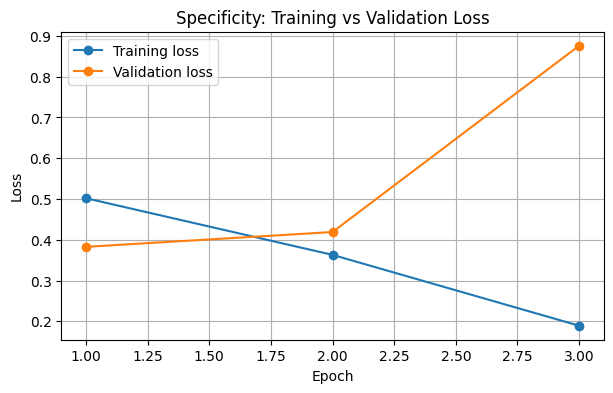

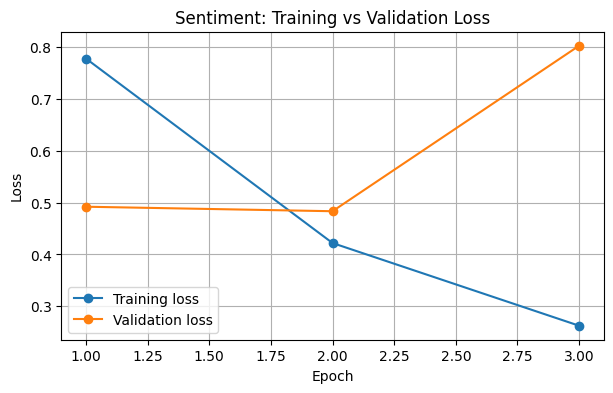

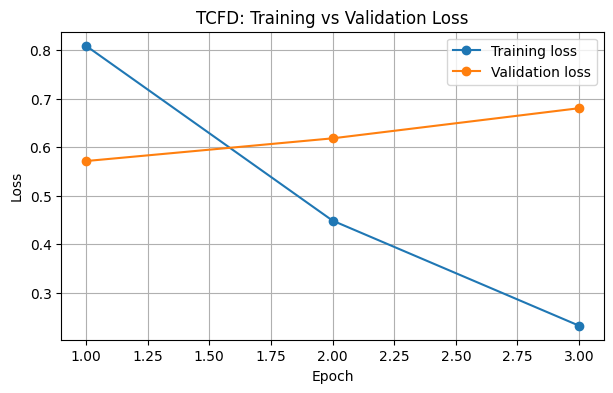

In [17]:
plot_loss(trainers["specificity_label"], "Specificity: Training vs Validation Loss")
plot_loss(trainers["sentiment_label"], "Sentiment: Training vs Validation Loss")
plot_loss(trainers["tcfd_label"], "TCFD: Training vs Validation Loss")

In [18]:
def get_predictions_df(trainer, train_df, test_df, label_col, label_map):
    _, _, test_part = prepare_task_data(
        train_df=train_df,
        test_df=test_df,
        text_col="text",
        label_col=label_col
    )

    ds_test = Dataset.from_pandas(test_part)
    ds_test = ds_test.map(tokenize_function, batched=True)

    keep_cols = ["input_ids", "attention_mask", "label"]
    ds_test = ds_test.remove_columns(
        [c for c in ds_test.column_names if c not in keep_cols]
    )

    pred_output = trainer.predict(ds_test)
    pred_labels = np.argmax(pred_output.predictions, axis=1)

    results = test_part.copy().reset_index(drop=True)
    results["pred_label"] = pred_labels
    results["correct"] = results["label"] == results["pred_label"]
    results["true_name"] = results["label"].map(label_map)
    results["pred_name"] = results["pred_label"].map(label_map)

    return results

In [19]:
label_maps = {
    "specificity_label": {
        0: "non-specific",
        1: "specific"
    },
    "sentiment_label": {
        0: "risk",
        1: "neutral",
        2: "opportunity"
    },
    "tcfd_label": {
        0: "none",
        1: "metrics",
        2: "strategy",
        3: "risk",
        4: "governance"
    }
}

results_spec = get_predictions_df(
    trainers["specificity_label"],
    train_merged,
    test_merged,
    "specificity_label",
    label_maps["specificity_label"]
)

results_sent = get_predictions_df(
    trainers["sentiment_label"],
    train_merged,
    test_merged,
    "sentiment_label",
    label_maps["sentiment_label"]
)

results_tcfd = get_predictions_df(
    trainers["tcfd_label"],
    train_merged,
    test_merged,
    "tcfd_label",
    label_maps["tcfd_label"]
)

Map: 100%|███████████████████████████| 320/320 [00:00<00:00, 8045.08 examples/s]


In [22]:
def plot_confusion_matrix(results_df, label_names, title):
    labels = list(range(len(label_names)))  

    cm = confusion_matrix(
        results_df["label"],
        results_df["pred_label"],
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

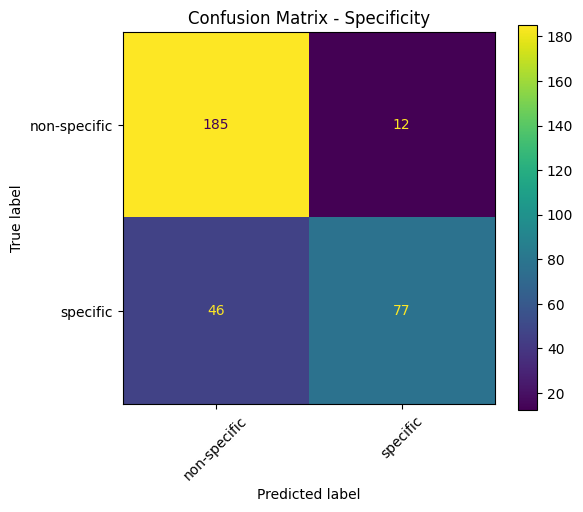

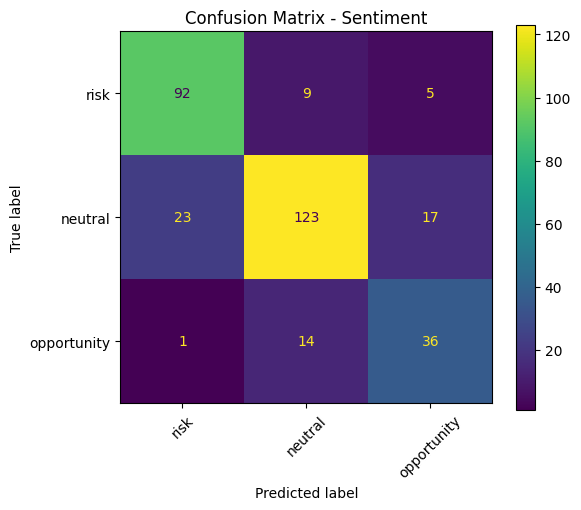

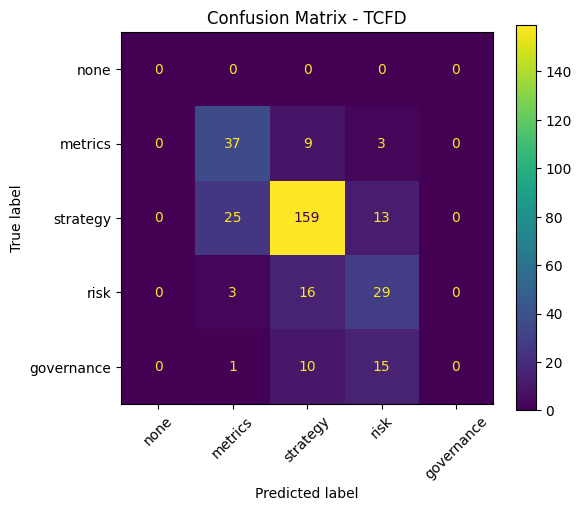

In [23]:
plot_confusion_matrix(
    results_spec,
    ["non-specific", "specific"],
    "Confusion Matrix - Specificity"
)

plot_confusion_matrix(
    results_sent,
    ["risk", "neutral", "opportunity"],
    "Confusion Matrix - Sentiment"
)

plot_confusion_matrix(
    results_tcfd,
    ["none", "metrics", "strategy", "risk", "governance"],
    "Confusion Matrix - TCFD"
)

# 5. Results and Analysis

## 5.1 Overall Performance

| Task               | Accuracy | F1 (macro) |
|--------------------|---------|-----------|
| Specificity        | 0.81    | 0.79      |
| Sentiment          | 0.78    | 0.76      |
| TCFD               | 0.70    | 0.50      |

The Table above summarizes the performance of the models across the three ESG classification tasks. The results show a clear performance hierarchy across tasks. Specificity achieves the highest performance, followed by sentiment, while TCFD classification presents significantly lower scores. This pattern suggests that model performance decreases as task complexity increases.

Specifically, specificity classification is a binary task with relatively explicit linguistic signals, often associated with numerical information or concrete statements. In contrast, sentiment classification introduces subjectivity, requiring the model to distinguish between nuanced categories such as risk, neutral, and opportunity. TCFD classification represents the most complex setting, involving multiple categories with overlapping semantic meanings and functional roles.

These results indicate that transformer-based models are highly effective when classification signals are explicit, but struggle in tasks that require deeper contextual reasoning or fine-grained distinctions.

## 5.2 Training Dynamics

To better understand model behavior during training, we analyze the evolution of training and validation loss across epochs. Across all tasks, the models exhibit rapid convergence, with most performance gains occurring within the first two epochs. This behavior is consistent with fine-tuning pretrained language models, where the initial representations already capture substantial linguistic structure.

However, a consistent pattern of overfitting is observed. While training loss decreases steadily, validation loss increases after early epochs, particularly for the specificity and sentiment tasks. This suggests that the models begin to memorize training data rather than generalize to unseen examples.

The effect is less pronounced in the TCFD task, likely due to its higher intrinsic complexity. In this case, the model struggles to fully fit the training data, resulting in a slower divergence between training and validation performance.

## 5.3 Task-Level Analysis

The specificity classification task achieves the highest performance among all tasks. The confusion matrix shows strong diagonal dominance, indicating that the model correctly identifies both specific and non-specific statements in most cases.

The sentiment classification task shows moderate performance, with most errors occurring between adjacent classes. In particular, confusion between neutral and risk or opportunity categories is common. This reflects the subjective nature of sentiment classification in ESG contexts, where distinctions are often subtle and context-dependent. 

The TCFD classification task presents the greatest challenge. The confusion matrix reveals substantial misclassification across categories, particularly between strategy, risk, and metrics. These categories often share similar vocabulary but differ in their functional role within a disclosure. For example, a statement describing climate-related risks may also implicitly refer to strategic considerations, making classification inherently ambiguous. The model appears to struggle a lot with distinguishing these functional differences, suggesting that surface-level semantic representations are insufficient for this task.

## 5.4 Error Analysis

To better understand model behavior, we perform a qualitative analysis of predictions across tasks. We first analyzed the specificity task by comparing correctly and incorrectly classified examples. The results show that the model performs well when explicit signals are present. Correct predictions are typically associated with clear linguistic markers, such as quantitative values, technical descriptions, or structured disclosures. In contrast, most misclassifications occur when specificity is expressed implicitly. Texts that describe concrete processes but lack numerical indicators are often predicted as non-specific. This suggests that the model relies heavily on surface-level cues rather than deeper semantic understanding.

For sentiment, correct predictions generally correspond to cases where sentiment is explicitly expressed. However, errors frequently arise in cases where tone is implicit or ambiguous. In particular, the model tends to confuse neutral statements with risk or opportunity when the text describes potential outcomes without a clear evaluative signal. This reflects the inherently subjective and context-dependent nature of sentiment classification in ESG disclosures.

For TCFD classification, misclassifications are concentrated between semantically related categories, particularly strategy, risk, and metrics. These categories often share similar vocabulary but differ in their functional role within a disclosure. The model frequently predicts "risk" for forward-looking or scenario-based descriptions, and "strategy" for governance-related content. This indicates that the model struggles to distinguish between closely related concepts that require deeper contextual and domain-specific understanding. These patterns are illustrated through representative examples from the TCFD classification task.

In [27]:
trainer = trainers["tcfd_label"]

# recreate test set
_, _, test_part = prepare_task_data(
    train_df=train_merged,
    test_df=test_merged,
    text_col="text",
    label_col="tcfd_label"
)

# turn into dataset
ds_test_tcfd = Dataset.from_pandas(test_part)

# tokenize
ds_test_tcfd = ds_test_tcfd.map(tokenize_function, batched=True)

# select columns
keep_cols = ["input_ids", "attention_mask", "label"]
ds_test_tcfd = ds_test_tcfd.remove_columns(
    [c for c in ds_test_tcfd.column_names if c not in keep_cols]
)

# prediction
pred_output = trainer.predict(ds_test_tcfd)

# logits -> class
pred_labels = np.argmax(pred_output.predictions, axis=1)

# create final dataframe
results_tcfd = test_part.copy().reset_index(drop=True)
results_tcfd["pred_label"] = pred_labels
results_tcfd["correct"] = results_tcfd["label"] == results_tcfd["pred_label"]

label_map = {
    0: "none",
    1: "metrics",
    2: "strategy",
    3: "risk",
    4: "governance"
}

results_tcfd["true_name"] = results_tcfd["label"].map(label_map)
results_tcfd["pred_name"] = results_tcfd["pred_label"].map(label_map)

# 5 correct examples
correct_examples_tcfd = (
    results_tcfd[results_tcfd["correct"]]
    .sample(5, random_state=42)[["text", "true_name", "pred_name"]]
)

# 5 wrong examples
incorrect_examples_tcfd = (
    results_tcfd[~results_tcfd["correct"]]
    .sample(5, random_state=42)[["text", "true_name", "pred_name"]]
)

print("Correct TCFD examples:")
display(correct_examples_tcfd.style.set_properties(subset=["text"], **{'white-space': 'pre-wrap'}))

print("\nIncorrect TCFD examples:")
display(incorrect_examples_tcfd.style.set_properties(subset=["text"], **{'white-space': 'pre-wrap'}))

Map: 100%|███████████████████████████| 320/320 [00:00<00:00, 8561.17 examples/s]


Correct TCFD examples:


,text,true_name,pred_name
10,Note: 1. Please refer to page 29 within Metrics & Targets for further details on our emissions and energy reduction targets. 2. This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.,metrics,metrics
257,"Rising public concern related to climate change has led and could lead to the adoption of worldwide laws and regulations which could result in a decrease of demand for hydrocarbons and increased compliance costs for the Company. Eni is also exposed to risks of technological breakthrough in the energy field and risks of extreme meteorological events linked to the climate change. All these developments may adversely affect the Group’s profitability, businesses outlook and reputation Growing worldwide public concern over greenhouse gas (GHG) emissions and climate change, as well as increasingly regulations in this area, could adversely affect the Group’s businesses and reputation, increase its operating costs and reduce its profitability and shareholders returns. Those risks may emerge in the short and medium-term, as well as over the long-term.",strategy,strategy
167,"With reference to the reuse of materials, the projects created in implementation of the Group’s investment plans for the Italian motorway network provided for the reuse - within the regulatory limits - of the earth deriving from excavations, in order to mitigate the environmental impact linked mainly to the procurement of inert quarry materials and the disposal in landfills of unused materials. They are reused to create embankments, landscaping and noise-absorbing dunes, as well as for the redevelopment of degraded areas (such as abandoned quarries).",strategy,strategy
291,"Nedbank committed R37,2bn limits at 31 December 2020 and has appetite to increase this to R50bn for the South African renewable energy independent power producer programme. Nedbank will further its embedded generation financing to accelerate the transition and accordingly aims to achieve R2bn in financing by 2022.",metrics,metrics
204,"Progress in 2020 • Review of the concept, categories, dimensions, methodology, roles and functions of socioenvironmental risk management and the definition of socioenvironmental risk factors; • Review of the socioenvironmental rating methodology; • Application of socioenvironmental rating to the business flow; • Creation of the Corporate Socioenvironmental Risk Management Manual; • Review of the Socioenvironmental Losses Base; • Revision of the Corporate Socioenvironmental Risk Indicators Manual; and • Inclusion of a socioenvironmental Indicator in the Master Plan.",risk,risk



Incorrect TCFD examples:


,text,true_name,pred_name
234,"The adoption of our climate strategy set in motion actions to help us achieve our climate-protection targets for 2030, 2040, and 2050 In monitoring progress toward them, it is important to remember that year-on- year comparisons can be affected by temporary fluctuations caused by weather patterns and other factors A period of several years is necessary to determine whether the action we take is effective and where we stand with regard to our targets We therefore assess our progress in greater depth every three years as part of a trend analysis Our first assessment was at year-end 2019 (relative to our former 2016 baseline after the Uniper spinoff) The trend (in absolute terms and with regard to our carbon intensity target) indicated that the reduction rate is in line with our forecasts",strategy,metrics
93,"The perceptions of the groups of stakeholders with whom we interact bring relevant inputs to the process of identifying our challenges and opportunities. Aiming to address perceptions, a review of the relevance of the categories of stakeholders was made in 2020 – board of directors, shareholders/investors, customers, entities affiliated, government, suppliers, employees, press/media, regulatory bodies, representatives of civil society, sustainability experts and competitors, from the perspective of the Strategic Objectives (2021-2025 Strategic Map) and the results of the process carried out in 2016.",strategy,risk
251,"Improving operational efficiency Our teams are dedicated to monitoring and optimising our roadside fix rate – one of our key performance metrics – which is not only better for our customers, but also means we reduce our mileage and only tow vehicles (the most carbon-intensive part of our service) where absolutely necessary. Taking this a stage further, we are also now operating Phone Fix, an initiative aimed at understanding customer requirements and fixing jobs over the phone. We are currently fixing approximately 1.3% of jobs over the phone, saving approximately 100,000 miles driven in the first half of 2020.",strategy,metrics
262,"Financial planning We acknowledge that there are risks posed by climate change that could potentially have impacts on revenue and costs, and we intend to integrate further climate- related considerations into our financial planning processes from 2021 onwards. As an underwriter, we actively measure climate-related risk through climate risk modelling due to the nature of the Group’s products (see page 25). We recognise our prices, products and operations will evolve as climate change influences manifest themselves through changing loss patterns.",risk,strategy
7,"Both our Board and executive leadership team recognize that operating responsibly, which includes minimizing the environmental impact of our operations, is fundamental to the long-term success of Verizon. We believe building a better future involves making climate aware- ness “business as usual” throughout our organization, starting at the top. This is why our Board’s oversight role and management governance structures are evolving to include more regular assessment and discussion of climate-related risks and opportunities.",governance,strategy


## 5.5 Multi-Label Interaction

Although each task is modeled independently, the overall problem is inherently multi-label. To evaluate joint performance, we compute the proportion of samples for which all labels are predicted correctly simultaneously.

The results show that joint performance is significantly lower than individual task performance, with a joint accuracy of 0.46 and a macro F1 score of 0.245. This indicates that errors accumulate across dimensions, even when each classifier performs reasonably well on its own.

This outcome is expected, as joint prediction is a stricter evaluation setting: a sample is considered correct only if all labels are predicted correctly at the same time. As a result, even small errors in individual tasks lead to a substantial drop in overall performance.

More importantly, this result highlights a fundamental limitation of decomposing multi-label problems into independent classification tasks. While each model captures patterns within its own dimension, dependencies between ESG attributes are not explicitly modeled. In practice, dimensions such as sentiment, specificity, and disclosure type may be correlated, but these relationships are ignored in the current approach.

These findings suggest that independently strong classifiers do not necessarily translate into strong multi-dimensional ESG understanding, reinforcing the need for joint modeling or more structured approaches.

In [30]:
df_joint = pd.DataFrame({
    "label": results_spec["label"],
    "pred_label": results_spec["pred_label"],
    "sent_true": results_sent["label"],
    "sent_pred": results_sent["pred_label"],
    "tcfd_true": results_tcfd["label"],
    "tcfd_pred": results_tcfd["pred_label"]
})

df_joint["true_joint"] = (
    df_joint["label"].astype(str) + "_" +
    df_joint["sent_true"].astype(str) + "_" +
    df_joint["tcfd_true"].astype(str)
)

df_joint["pred_joint"] = (
    df_joint["pred_label"].astype(str) + "_" +
    df_joint["sent_pred"].astype(str) + "_" +
    df_joint["tcfd_pred"].astype(str)
)

# metrics
joint_accuracy = accuracy_score(df_joint["true_joint"], df_joint["pred_joint"])
joint_f1_macro = f1_score(df_joint["true_joint"], df_joint["pred_joint"], average="macro")

print(f"Joint Accuracy: {joint_accuracy:.2f}")
print(f"Joint F1 (macro): {joint_f1_macro:.2f}")

Joint Accuracy: 0.46
Joint F1 (macro): 0.25


# 6. Architectural Framework for ESG Taxonomy Classification

While previous sections focused on modeling ESG dimensions as independent classification tasks, real-world applications such as sustainable taxonomy alignment require a significantly more complex system architecture. In practice, data is rarely structured, complete, or directly aligned with predefined taxonomy criteria. Instead, it is typically fragmented across textual descriptions, partially structured fields, and long-form reports.

In practice, ESG data is predominantly unstructured. Information is often embedded in textual descriptions, incomplete records, or large documents such as sustainability reports.

This scenario introduces several challenges:

* Missing or inconsistent structured fields
* Ambiguity in textual descriptions
* Lack of direct mapping between text and taxonomy criteria
* High variability in language and reporting styles

To address these challenges, a multi-stage NLP pipeline is required, combining preprocessing, representation learning, and classification.


![](Figure1.jpg)



We define a modular, layered architecture for solving the ESG taxonomy classification problem, as illustrated in the Figure above. Each layer transforms the data progressively, moving from raw inputs to structured, explainable decisions.


# 7. Final Discussion

This work explored ESG text classification using transformer-based models and subsequently proposed a broader architectural framework for taxonomy-aligned decision systems. While the experimental results demonstrate that transformer models can effectively capture certain ESG dimensions, such as specificity and sentiment, they also reveal an important limitation: ESG taxonomy classification cannot be fully addressed as a standalone text classification problem.

An important empirical observation is the uneven performance across ESG dimensions, reflecting differences in semantic clarity and task complexity. While dimensions such as specificity exhibit strong performance due to clearer linguistic patterns and more direct signals in the text, others, such as TCFD classification, show significantly lower performance. This suggests that some ESG dimensions involve higher levels of abstraction, ambiguity, and overlap between categories, making them inherently more difficult to model.

These results indicate that ESG classification does not scale linearly with the number of dimensions. As additional criteria are introduced, the problem becomes increasingly complex due to semantic heterogeneity and interdependence between tasks. In this context, treating each dimension as an independent classification problem may limit generalization, as it fails to capture the structured relationships required for real-world decision-making.

This limitation highlights a fundamental mismatch between traditional NLP approaches and the requirements of sustainability taxonomies. In practice, taxonomy alignment requires combining multiple dimensions, applying threshold-based criteria, and integrating structured domain knowledge. The layered architecture proposed in this work addresses this gap by separating semantic representation from decision-making, allowing each component of the system to handle a different aspect of the problem.

However, the experimental setup presented in this work remains a simplified proxy of this broader problem. It relies on curated datasets and independent classification tasks, which do not fully capture the complexity of real-world ESG disclosures and taxonomy requirements. In particular, the absence of joint modeling across dimensions and the lack of explicit integration with real taxonomy criteria limit the direct applicability of the results.

Despite these limitations, the findings provide useful insights into the challenges of ESG modeling and motivate the need for more structured approaches. 

# References

[1] Webersinke, N., Kraus, M., Bingler, J., Kraus, S., & Leippold, M. (2021). ClimateBERT: A Pretrained Language Model for Climate-Related Text. arXiv preprint arXiv:2110.12010.